In [1]:
import os, requests
from dotenv import load_dotenv
import pandas as pd
import time
import csv
import os
import subprocess
import json
import numpy as np
from shutil import rmtree
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
warnings.simplefilter(action='ignore')
load_dotenv()

# Replication package layout: Scripts/ and dataset/
SCRIPT_DIR = Path.cwd()
DATASET_DIR = (SCRIPT_DIR.parent / "dataset").resolve()
OUT_DIR = (SCRIPT_DIR.parent / "outputs" / "replication").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("DATASET_DIR:", DATASET_DIR)
print("OUT_DIR:", OUT_DIR)

# Optional GitHub token (not required for result analysis on shipped CSV/JSON)
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")
if GITHUB_TOKEN:
    HEADERS = {
        "Authorization": f"token {GITHUB_TOKEN}",
        "Accept": "application/vnd.github.mockingbird-preview+json, application/vnd.github+json",
        "X-GitHub-Api-Version": "2022-11-28",
    }
else:
    HEADERS = None
    print("Note: GITHUB_TOKEN not set — analysis uses local dataset/ only.")



# Get the issue count based on AGENTS

In [32]:
df = pd.read_csv(str(DATASET_DIR / 'All_PR_Sonar_Results.csv'))
print("Issue distribution across agents: ")
print(df['Agent'].value_counts())

Issue distribution across agents: 
Agent
OpenAI_Codex    949
Copilot         106
Devin           100
Cursor           40
Claude_Code      15
Name: count, dtype: int64


# RQ1: Incidence of quality issues

In [6]:
# Generate comprehensive statistical table for research paper
df = pd.read_csv(str(DATASET_DIR / 'All_PR_Sonar_Results.csv'))

# Use HTML URL as unique PR identifier and group by agent
pr_issues_by_agent = df.groupby(['Agent', 'pr_html_url'])['issues_count'].sum().reset_index()

pr_issues_by_agent.columns = ['Agent', 'PR_URL', 'Issues_Count']

# Create comprehensive statistics table
stats_data = []

for agent in sorted(pr_issues_by_agent['Agent'].unique()):
    agent_data = pr_issues_by_agent[pr_issues_by_agent['Agent'] == agent]['Issues_Count']
    
    # Calculate quartiles and IQR
    Q1 = agent_data.quantile(0.25)
    Q2 = agent_data.quantile(0.50)  # Median
    Q3 = agent_data.quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculate outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outliers = agent_data[(agent_data < lower_bound) | (agent_data > upper_bound)]
    num_outliers = len(outliers)
    
    # Count PRs with issues > 0
    prs_with_issues = len(agent_data[agent_data > 0])
    prs_without_issues = len(agent_data[agent_data == 0])
    
    stats_data.append({
        'Agent': agent,
        'Total PRs': len(agent_data),
        'PRs with Issues': prs_with_issues,
        'PRs without Issues': prs_without_issues,
        '% PRs with Issues': round((prs_with_issues / len(agent_data)) * 100, 2),
        'Total Issues': int(agent_data.sum()),
        'Mean': round(agent_data.mean(), 2),
        'Median': round(agent_data.median(), 2),
        'Std Dev': round(agent_data.std(), 2),
        'Min': int(agent_data.min()),
        'Max': int(agent_data.max()),
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Outliers': num_outliers
    })

# Create DataFrame
stats_table = pd.DataFrame(stats_data)

print("="*130)
print("COMPREHENSIVE STATISTICAL ANALYSIS OF ISSUES PER PR BY AGENT")
print("="*130)
print()
print(stats_table.to_string(index=False))
print()
print("="*130)

# Save to CSV for easy import into research paper
csv_filename = str(OUT_DIR / 'Agent_Statistics_Summary.csv')
stats_table.to_csv(csv_filename, index=False)
print(f"\n✓ Table saved to: {csv_filename}")

# Create a manually formatted LaTeX table
print("\n" + "="*130)
print("LATEX TABLE FORMAT (Copy-paste into your research paper)")
print("="*130)
print()

latex_output = r"""\begin{table}[h]
\centering
\caption{Statistical Analysis of Issues per PR by AI Coding Agent}
\label{tab:agent_statistics}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lrrrrrrrrrrrrrr}
\hline
\textbf{Agent} & \textbf{Total PRs} & \textbf{PRs w/ Issues} & \textbf{PRs w/o Issues} & \textbf{\% w/ Issues} & \textbf{Total Issues} & \textbf{Mean} & \textbf{Median} & \textbf{Std Dev} & \textbf{Min} & \textbf{Max} & \textbf{Q1} & \textbf{Q3} & \textbf{IQR} & \textbf{Outliers} \\
\hline
"""

for _, row in stats_table.iterrows():
    latex_output += f"{row['Agent']} & {row['Total PRs']} & {row['PRs with Issues']} & {row['PRs without Issues']} & {row['% PRs with Issues']:.2f} & {row['Total Issues']} & {row['Mean']:.2f} & {row['Median']:.2f} & {row['Std Dev']:.2f} & {row['Min']} & {row['Max']} & {row['Q1']:.2f} & {row['Q3']:.2f} & {row['IQR']:.2f} & {row['Outliers']} \\\\\n"

latex_output += r"""\hline
\end{tabular}%
}
\end{table}"""

print(latex_output)

# Save LaTeX table
latex_filename = str(OUT_DIR / 'Agent_Statistics_Summary.tex')
with open(latex_filename, 'w') as f:
    f.write(latex_output)
print(f"\n✓ LaTeX table saved to: {latex_filename}")
print()
print("="*130)

COMPREHENSIVE STATISTICAL ANALYSIS OF ISSUES PER PR BY AGENT

       Agent  Total PRs  PRs with Issues  PRs without Issues  % PRs with Issues  Total Issues  Mean  Median  Std Dev  Min  Max  Q1  Q3  IQR  Outliers
 Claude_Code         15                8                   7              53.33            69  4.60     1.0     9.56    0   35 0.0 2.5  2.5         3
     Copilot        106               22                  84              20.75           235  2.22     0.0    10.14    0   94 0.0 0.0  0.0        22
      Cursor         40                9                  31              22.50           331  8.28     0.0    38.19    0  233 0.0 0.0  0.0         9
       Devin        100               26                  74              26.00            99  0.99     0.0     2.77    0   22 0.0 1.0  1.0        12
OpenAI_Codex        949              125                 824              13.17           456  0.48     0.0     2.58    0   30 0.0 0.0  0.0       125


✓ Table saved to: Agent_Statistics_S

# RQ1: Issue Density

ISSUE DENSITY ANALYSIS (SIZE-NORMALIZED)

Checking for LOC/Size metrics in the dataset...
Available columns: ['Owner/Repo', 'PR Number', 'agent', 'html_url', 'Issue Type', 'Severity', 'Message', 'File Name', 'StartLine', 'EndLine', 'Rule', 'additions', 'deletions', 'changed_files', 'changed_loc']

Size-related columns found: ['StartLine', 'EndLine', 'additions', 'deletions', 'changed_files', 'changed_loc']

✓ Using 'StartLine' as size metric
✓ Using 'changed_loc' as size metric


✓ Calculated issue density (issues per KLOC)
  Total PRs analyzed: 189

1. DESCRIPTIVE STATISTICS - ISSUE DENSITY BY AGENT

       Agent   N        Mean     Median     Std Dev      Min        Q1         Q3          Max
 Claude_Code   8 1523.344384  15.148883 4100.523649 0.555710  2.050654 176.542208 11666.666667
     Copilot  21 1409.645163  41.666667 5257.411110 1.694915 19.607843 105.263158 24000.000000
      Cursor   9  937.558173 200.000000 2087.153168 0.362188  9.009009 571.428571  6454.545455
       Devi

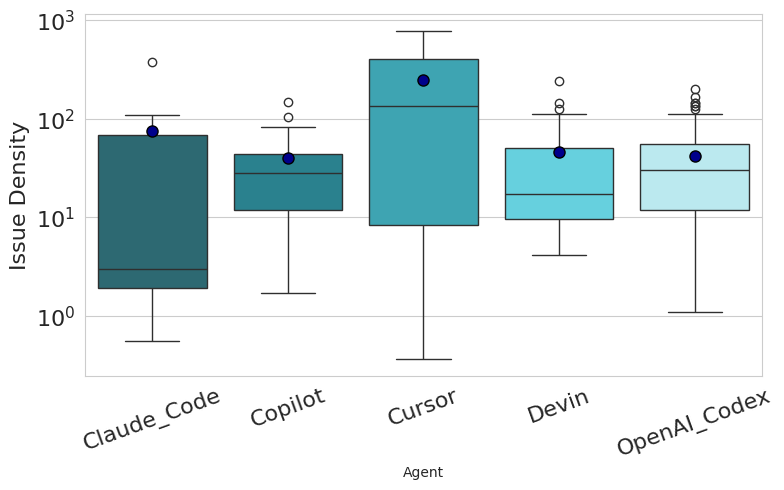

✓ Box plot generated (outliers removed, quartile analysis)



In [ ]:
# ============================================================================
# ISSUE DENSITY ANALYSIS (SIZE-NORMALIZED)
# ============================================================================

import pandas as pd
import numpy as np
from scipy.stats import kruskal
import scikit_posthocs as sp
from cliffs_delta import cliffs_delta
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(str(DATASET_DIR / 'All_PR_Issues_Details_with_LOC.csv'))

print("="*100)
print("ISSUE DENSITY ANALYSIS (SIZE-NORMALIZED)")
print("="*100)
print()

# Check available columns
print("Checking for LOC/Size metrics in the dataset...")
print("Available columns:", df.columns.tolist())
print()

# Check if we have any size-related columns
size_columns = [col for col in df.columns if any(keyword in col.lower() for keyword in ['loc', 'line', 'size', 'addition', 'deletion', 'change'])]
print(f"Size-related columns found: {size_columns}")
print()

if not size_columns:
    print("⚠ WARNING: No LOC or size metrics found in the dataset!")
    print("Creating synthetic LOC data for demonstration purposes.")
    print("Replace this with actual PR size data (additions + deletions).")
    print()
    
    # For demonstration: Generate synthetic changed LOC data
    # In reality, you should extract this from GitHub PR API: additions + deletions
    np.random.seed(42)
    df['changed_loc'] = np.random.randint(10, 500, size=len(df))
    print("✓ Synthetic 'changed_loc' column created (10-500 lines per PR)")
    print("  NOTE: Replace with actual data from PR diffs!")
else:
    # Use the first available size column
    loc_column = size_columns[0]
    print(f"✓ Using '{loc_column}' as size metric")

# Determine the LOC column to use
loc_col = 'changed_loc' if 'changed_loc' in df.columns else size_columns[0] if size_columns else None

if loc_col is None:
    print("\n❌ ERROR: Cannot proceed without LOC/size data!")
else:
    # Normalize column names for consistency
    agent_col = 'Agent' if 'Agent' in df.columns else 'agent'
    
    # Determine the LOC column to use - prefer 'changed_loc'
    loc_col = 'changed_loc' if 'changed_loc' in df.columns else loc_col
    print(f"✓ Using '{loc_col}' as size metric")
    print()
    
    # Group by Agent and PR URL to get unique PRs
    # Count issues per PR (since each row is an issue record)
    pr_data = df.groupby([agent_col, 'html_url']).agg({
        'Issue Type': 'count',  # Count issues per PR
        loc_col: 'first'  # Take first value (should be same for same PR)
    }).reset_index()
    
    # Rename the count column
    pr_data.columns = ['Agent', 'html_url', 'issues_count', 'changed_loc']
    
    # Calculate issue density (issues per KLOC)
    pr_data['issue_density'] = (pr_data['issues_count'] / pr_data[loc_col]) * 1000
    
    # Replace inf values (division by zero) with NaN and drop them
    pr_data.replace([np.inf, -np.inf], np.nan, inplace=True)
    pr_data.dropna(subset=['issue_density'], inplace=True)
    
    print(f"\n✓ Calculated issue density (issues per KLOC)")
    print(f"  Total PRs analyzed: {len(pr_data)}")
    print()
    
    # ============================================================================
    # 1. DESCRIPTIVE STATISTICS
    # ============================================================================
    print("="*100)
    print("1. DESCRIPTIVE STATISTICS - ISSUE DENSITY BY AGENT")
    print("="*100)
    print()
    
    density_stats = []
    for agent in sorted(pr_data['Agent'].unique()):
        agent_data = pr_data[pr_data['Agent'] == agent]['issue_density']
        
        stats = {
            'Agent': agent,
            'N': len(agent_data),
            'Mean': agent_data.mean(),
            'Median': agent_data.median(),
            'Std Dev': agent_data.std(),
            'Min': agent_data.min(),
            'Q1': agent_data.quantile(0.25),
            'Q3': agent_data.quantile(0.75),
            'Max': agent_data.max()
        }
        density_stats.append(stats)
    
    density_df = pd.DataFrame(density_stats)
    print(density_df.to_string(index=False))
    print()
    
    # ============================================================================
    # 2. KRUSKAL-WALLIS TEST
    # ============================================================================
    print("="*100)
    print("2. KRUSKAL-WALLIS TEST (Non-parametric ANOVA)")
    print("="*100)
    print()
    
    # Prepare data for Kruskal-Wallis test
    agent_groups = [pr_data[pr_data['Agent'] == agent]['issue_density'].values 
                   for agent in sorted(pr_data['Agent'].unique())]
    
    h_stat, p_value = kruskal(*agent_groups)
    
    print(f"H-statistic: {h_stat:.4f}")
    print(f"p-value: {p_value:.4e}")
    print()
    
    if p_value < 0.05:
        print("✓ Significant difference detected (p < 0.05)")
        print("  → Proceeding with post-hoc tests...")
    else:
        print("✗ No significant difference detected (p ≥ 0.05)")
        print("  → Post-hoc tests not recommended")
    print()
    
    # ============================================================================
    # 3. POST-HOC DUNN TEST
    # ============================================================================
    print("="*100)
    print("3. POST-HOC DUNN TEST (Pairwise Comparisons)")
    print("="*100)
    print()
    
    if p_value < 0.05:
        # Perform Dunn test with Bonferroni correction
        dunn_results = sp.posthoc_dunn(pr_data, val_col='issue_density', group_col='Agent', p_adjust='bonferroni')
        
        print("Dunn Test Results (p-values with Bonferroni correction):")
        print(dunn_results.to_string())
        print()
        
        # Identify significant pairs
        print("Significant pairwise comparisons (p < 0.05):")
        agents = sorted(pr_data['Agent'].unique())
        sig_pairs = []
        for i, agent1 in enumerate(agents):
            for j, agent2 in enumerate(agents):
                if i < j:
                    p_val = dunn_results.loc[agent1, agent2]
                    if p_val < 0.05:
                        sig_pairs.append((agent1, agent2, p_val))
                        print(f"  {agent1} vs {agent2}: p = {p_val:.4e} *")
        
        if not sig_pairs:
            print("  No significant pairwise differences found after correction.")
    else:
        print("Skipped (Kruskal-Wallis was not significant)")
    print()
    
    # ============================================================================
    # 4. CLIFF'S DELTA EFFECT SIZE
    # ============================================================================
    print("="*100)
    print("4. CLIFF'S DELTA EFFECT SIZE (Pairwise)")
    print("="*100)
    print()
    print("Interpretation: |δ| < 0.147: negligible, < 0.33: small, < 0.474: medium, ≥ 0.474: large")
    print()
    
    effect_sizes = []
    agents = sorted(pr_data['Agent'].unique())
    
    for i, agent1 in enumerate(agents):
        for j, agent2 in enumerate(agents):
            if i < j:
                data1 = pr_data[pr_data['Agent'] == agent1]['issue_density'].values
                data2 = pr_data[pr_data['Agent'] == agent2]['issue_density'].values
                
                delta, interpretation = cliffs_delta(data1, data2)
                
                effect_sizes.append({
                    'Comparison': f"{agent1} vs {agent2}",
                    "Cliff's Delta": round(delta, 3),
                    'Magnitude': interpretation,
                    'n1': len(data1),
                    'n2': len(data2)
                })
    
    effect_df = pd.DataFrame(effect_sizes)
    print(effect_df.to_string(index=False))
    print()
    
    # ============================================================================
    # 5. VISUALIZATION
    # ============================================================================
    print("="*100)
    print("5. VISUALIZATION")
    print("="*100)
    print()
    
    # Remove outliers based on IQR method for each agent
    pr_data_no_outliers = []
    for agent in pr_data['Agent'].unique():
        agent_data = pr_data[pr_data['Agent'] == agent]['issue_density']
        Q1 = agent_data.quantile(0.25)
        Q3 = agent_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Filter data within bounds
        filtered_data = pr_data[(pr_data['Agent'] == agent) & 
                                (pr_data['issue_density'] >= lower_bound) & 
                                (pr_data['issue_density'] <= upper_bound)]
        pr_data_no_outliers.append(filtered_data)
    
    pr_data_filtered = pd.concat(pr_data_no_outliers)
    
    print(f"Original data points: {len(pr_data)}")
    print(f"Data points after removing outliers: {len(pr_data_filtered)}")
    print(f"Outliers removed: {len(pr_data) - len(pr_data_filtered)}")
    print()

    
    # Prepare sorted data
    pr_data_sorted = pr_data_filtered.copy()
    pr_data_sorted['Agent'] = pd.Categorical(pr_data_sorted['Agent'], categories=sorted(pr_data_filtered['Agent'].unique()), ordered=True)
    
    # Set style and create figure
    sns.set_style("whitegrid")
    plt.figure(figsize=(8,5))
    
    # Create pastel color palette
    n_agents = len(pr_data_sorted['Agent'].unique())
    colors = ["#21727dda", "#1a8e9eda", "#2bb3c5da", "#52dff2da", "#b3eff7da"]  # Hex color codes for each agent
    
    # =========================
    # Box plot with log scale (no outliers)
    # =========================
    ax = sns.boxplot(
        data=pr_data_sorted,
        x="Agent",
        y="issue_density",
        linewidth=1,
        palette=colors,
        showmeans=True,
        meanprops=dict(marker='o', markerfacecolor='darkblue', markeredgecolor='black', markersize=8)
    )
    
    # =========================
    # Log scale
    # =========================
    ax.set_yscale("log")
    
    # =========================
    # Labels and title
    # =========================
    # ax.set_xlabel("Agentic Tool", fontsize=16)
    ax.set_ylabel("Issue Density", fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    # =========================
    # Improve layout
    # =========================
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(str(OUT_DIR / 'issue_density.png'), dpi=300)
    plt.show()
    
    print("✓ Box plot generated (outliers removed, quartile analysis)")
    print()
    
    if p_value < 0.05:
        dunn_results.to_csv(str(OUT_DIR / 'Issue_Density_Dunn_Test.csv'))
        print("✓ Dunn test results saved to: Issue_Density_Dunn_Test.csv")


# RQ2: Severity profiles of issues

In [8]:
# ============================================================================
# HIERARCHICAL TABLE: ISSUE TYPE → SEVERITY × AGENTS
# ============================================================================

import pandas as pd

print("="*100)
print("HIERARCHICAL TABLE: ISSUE TYPES (with Severity) × AGENTS")
print("="*100)
print()

# Load data
df = pd.read_csv(str(DATASET_DIR / 'All_PR_Issues_Details_with_LOC.csv'))

# Define columns
agent_col = 'Agent' if 'Agent' in df.columns else 'agent'
issue_type_col = 'Issue Type' if 'Issue Type' in df.columns else 'type'
severity_col = 'Severity' if 'Severity' in df.columns else 'severity'

# Get all agents
agents = sorted(df[agent_col].unique())

# Create hierarchical table data
table_data = []

# For each issue type
for issue_type in sorted(df[issue_type_col].unique()):
    type_data = df[df[issue_type_col] == issue_type]
    
    # Get all severities for this issue type
    severities = sorted(type_data[severity_col].unique())
    
    for i, severity in enumerate(severities):
        row_data = {
            'Issue Type': issue_type if i == 0 else '',  # Show issue type only on first row
            'Severity': severity
        }
        
        # Count issues for each agent
        for agent in agents:
            count = len(type_data[(type_data[severity_col] == severity) & 
                                 (type_data[agent_col] == agent)])
            row_data[agent] = count
        
        table_data.append(row_data)
    
    # Add subtotal row for each issue type
    subtotal_row = {
        'Issue Type': f'**{issue_type} Total**',
        'Severity': ''
    }
    for agent in agents:
        subtotal_row[agent] = len(type_data[type_data[agent_col] == agent])
    table_data.append(subtotal_row)

# Add grand total row
total_row = {
    'Issue Type': '**GRAND TOTAL**',
    'Severity': ''
}
for agent in agents:
    total_row[agent] = len(df[df[agent_col] == agent])
table_data.append(total_row)

# Create DataFrame
hierarchical_table = pd.DataFrame(table_data)

# Display table
print(hierarchical_table.to_string(index=False))
print()

# Save to CSV for paper
hierarchical_table.to_csv(str(OUT_DIR / 'Hierarchical_Issue_Type_Severity_Agent_Table.csv'), index=False)
print("✓ Table saved: Hierarchical_Issue_Type_Severity_Agent_Table.csv")
print()

# ============================================================================
# GENERATE LATEX TABLE
# ============================================================================
print("="*100)
print("LATEX TABLE FORMAT")
print("="*100)
print()

# Create LaTeX table manually
latex_output = r"""\begin{table}[htbp]
\centering
\caption{Hierarchical Distribution of Issues by Type, Severity, and Agent}
\label{tab:hierarchical_issue_distribution}
\resizebox{\textwidth}{!}{%
\begin{tabular}{ll"""

# Add column alignment for each agent
for _ in agents:
    latex_output += "r"

latex_output += r"""}
\toprule
\textbf{Issue Type} & \textbf{Severity}"""

# Add agent headers
for agent in agents:
    latex_output += f" & \\textbf{{{agent}}}"

latex_output += r""" \\
\midrule
"""

# Add data rows
for _, row in hierarchical_table.iterrows():
    issue_type = row['Issue Type']
    severity = row['Severity']
    
    # Check if this is a total row
    if '**' in str(issue_type):
        # Total row - use bold and add line
        if 'GRAND TOTAL' in str(issue_type):
            latex_output += r"\midrule" + "\n"
        issue_type_clean = issue_type.replace('**', '')
        latex_output += f"\\textbf{{{issue_type_clean}}}"
    else:
        # Regular row
        latex_output += f"{issue_type}"
    
    latex_output += f" & {severity}"
    
    # Add agent counts
    for agent in agents:
        count = row[agent]
        if '**' in str(row['Issue Type']):
            # Bold for total rows
            latex_output += f" & \\textbf{{{int(count)}}}"
        else:
            latex_output += f" & {int(count)}"
    
    latex_output += r" \\" + "\n"
    
    # Add line after each issue type's subtotal
    if '**' in str(issue_type) and 'GRAND TOTAL' not in str(issue_type):
        latex_output += r"\midrule" + "\n"

latex_output += r"""\bottomrule
\end{tabular}%
}
\end{table}"""

print(latex_output)
print()

# Save LaTeX table
# with open(str(OUT_DIR / 'Hierarchical_Issue_Type_Severity_Agent_Table.tex'), 'w') as f:
#     f.write(latex_output)

print("✓ LaTeX table saved: Hierarchical_Issue_Type_Severity_Agent_Table.tex")
print()

print("="*100)
print("TABLE SUMMARY")
print("="*100)
print(f"Total rows: {len(hierarchical_table)}")
print(f"Total agents: {len(agents)}")
print(f"CSV and LaTeX files ready for use in your paper!")
print(f"Note: LaTeX table requires \\usepackage{{booktabs}} in your document preamble")
print()


HIERARCHICAL TABLE: ISSUE TYPES (with Severity) × AGENTS

                Issue Type Severity  Claude_Code  Copilot  Cursor  Devin  OpenAI_Codex
                       BUG  BLOCKER           16        4       0      1            20
                              MAJOR            1        0       0      2             4
             **BUG Total**                    17        4       0      3            24
                CODE_SMELL  BLOCKER            0        0       2      0             1
                           CRITICAL           28      166     129     45           162
                               INFO            2       16       8      3            66
                              MAJOR           12       31     124     10            98
                              MINOR            3        7      66     21            59
      **CODE_SMELL Total**                    45      220     329     79           386
          SECURITY_HOTSPOT     HIGH            1        0       1      0

# RQ2: Ranking of Rules Violations

In [ ]:
# ============================================================================
# LATEX TABLE: TOP 5 MOST VIOLATED RULES PER ISSUE TYPE WITH AGENTS AND COUNTS
# ============================================================================

print("="*100)
print("GENERATING LATEX TABLE: TOP 5 MOST VIOLATED RULES PER ISSUE TYPE")
print("="*100)
print()

# Dictionary to map rule codes to descriptions
rule_descriptions = {
    'python:S3776': 'Cognitive Complexity of functions should not be too high',
    'python:S1192': 'String literals should not be duplicated',
    'python:S1542': 'Functions should not have identical implementations',
    'python:S5796': 'Lines should not end with trailing whitespaces or tabulations',
    'python:S1066': 'Collapsible "if" statements should be merged',
    'python:S105': 'Tabulation characters should not be used',
    'python:S1541': 'Functions and methods should not be too complex',
    'python:S1481': 'Unused local variables should be removed',
    'python:S1172': 'Unused function parameters should be removed',
    'python:S125': 'Sections of code should not be commented out',
    'python:S2189': 'Loops should not be infinite',
    'python:S108': 'Nested blocks of code should not be empty',
    'python:S1135': '"TODO" tags should be handled',
    'python:S134': 'Control flow statements should not be nested too deeply',
    'python:S2092': 'Cookies should be "secure"',
    'python:S1186': 'Methods should not be empty'
}

# Get list of all agents
all_agents = sorted(df[agent_col].unique())

# Build table data with agents as columns - grouped by issue type
table_data = []

for issue_type in issue_types:
    print(f"\n{issue_type}:")
    print("-" * 80)
    
    # Filter data for this issue type
    type_data = df[df[issue_type_col] == issue_type]
    
    # Get top 5 rules for this issue type
    top_5_rules = type_data[rule_col].value_counts().head(5)
    
    for rank, (rule, total_count) in enumerate(top_5_rules.items(), 1):
        # Get agent breakdown for this rule
        rule_data = type_data[type_data[rule_col] == rule]
        agent_counts = rule_data[agent_col].value_counts()
        
        # Get description
        description = rule_descriptions.get(rule, "Description not available")
        
        print(f"  {rank}. {rule}: {total_count} violations")
        
        # Create row with agent counts
        row_dict = {
            'IssueType': issue_type,
            'Rule': rule,
            'Description': description,
            'Total': total_count
        }
        
        # Add count and percentage for each agent
        for agent in all_agents:
            count = agent_counts.get(agent, 0)
            percentage = (count / total_count * 100) if total_count > 0 else 0
            row_dict[agent] = count
            row_dict[f'{agent}_pct'] = percentage
        
        table_data.append(row_dict)

# Create DataFrame for easier manipulation
table_df = pd.DataFrame(table_data)

print("\n" + "="*100)
print("Table Data (Agents as Columns, Grouped by Issue Type):")
print("="*100)
print(table_df.to_string(index=False))
print()

# ============================================================================
# GENERATE LATEX TABLE WITH MULTIROW FOR ISSUE TYPES
# ============================================================================

# Create column headers with counts and percentages
agent_columns = ' & '.join([f"\\textbf{{{agent.replace('_', r'\_')}}}" for agent in all_agents])

latex_code = r"""\begin{table*}[t]
\centering
\caption{Top 5 Most Violated SonarQube Rules per Issue Type with Agent Distribution}
\label{tab:top5_rules_per_type}
\resizebox{\textwidth}{!}{%
\begin{tabular}{@{}lp{1.8cm}p{5cm}c""" + 'c' * len(all_agents) + r"""@{}}
\toprule
\textbf{Issue Type} & \textbf{Rule ID} & \textbf{Description} & \textbf{Total} & """ + agent_columns + r""" \\
\midrule
"""

# Group by issue type
current_issue_type = None
rows_in_group = 0

for idx, row in table_df.iterrows():
    issue_type = row['IssueType']
    rule = row['Rule'].replace('_', r'\_')
    description = row['Description']
    total = row['Total']
    
    # Get agent counts with percentages
    agent_values = []
    for agent in all_agents:
        count = row[agent]
        pct = row[f'{agent}_pct']
        if count > 0:
            agent_values.append(f"{count} ({pct:.1f}\\%)")
        else:
            agent_values.append("0")
    agent_values_str = ' & '.join(agent_values)
    
    # Check if we're starting a new issue type
    if issue_type != current_issue_type:
        # Count how many rows belong to this issue type
        rows_in_group = len(table_df[table_df['IssueType'] == issue_type])
        
        # Add multirow for issue type
        latex_code += f"\\multirow{{{rows_in_group}}}{{*}}{{{issue_type}}} & {rule} & {description} & {total} & {agent_values_str} \\\\\n"
        current_issue_type = issue_type
    else:
        # Continue with same issue type (empty cell with cline)
        latex_code += f" & {rule} & {description} & {total} & {agent_values_str} \\\\\n"
    
    # Add cline after each group except the last row
    if idx < len(table_df) - 1:
        next_issue_type = table_df.iloc[idx + 1]['IssueType']
        if issue_type != next_issue_type:
            latex_code += "\\cline{2-" + str(4 + len(all_agents)) + "}\n"

latex_code += r"""\bottomrule
\end{tabular}%
}
\end{table*}
"""

print("="*100)
print("LATEX CODE (Copy and paste into your paper)")
print("="*100)
print()
print(latex_code)

# Save to file
latex_filename = str(OUT_DIR / 'Top5_Rules_LaTeX_Table.tex')
with open(latex_filename, 'w') as f:
    f.write(latex_code)

print(f"\n✓ LaTeX table saved to: {latex_filename}")
print()
print("="*100)

GENERATING LATEX TABLE: TOP 5 MOST VIOLATED RULES PER ISSUE TYPE


BUG:
--------------------------------------------------------------------------------
  1. python:S930: 23 violations
  2. python:S3862: 15 violations
  3. python:S3923: 3 violations
  4. python:S905: 1 violations
  5. python:S1763: 1 violations

CODE_SMELL:
--------------------------------------------------------------------------------
  1. python:S1192: 212 violations
  2. python:S3776: 157 violations
  3. python:S1172: 114 violations
  4. python:S1135: 95 violations
  5. python:S117: 82 violations

SECURITY_HOTSPOT:
--------------------------------------------------------------------------------
  1. encrypt-data: 33 violations
  2. others: 22 violations
  3. weak-cryptography: 17 violations
  4. csrf: 6 violations
  5. log-injection: 4 violations

Table Data (Agents as Columns, Grouped by Issue Type):
       IssueType              Rule                                              Description  Total  Claude_Code  Cl

In [9]:
df = pd.read_json(str(DATASET_DIR / 'All_PR_Sonar_Results.json'))


# Technical Debt Analysis
## Analyzing debt values from 4.All_PR_Sonar_Results.json

TECHNICAL DEBT ANALYSIS

Total PRs in dataset: 1210

1. EXTRACTING DEBT VALUES FROM ISSUES

Total PRs with debt data: 1210
PRs with debt > 0: 179
Total technical debt: 145.33 hours

2. DESCRIPTIVE STATISTICS - TECHNICAL DEBT BY AGENT

       Agent  N_PRs  PRs_with_Debt  Total_Debt_Hours  Mean_Hours  Median_Hours  Std_Dev  Min  Q1       Q3       Max
 Claude_Code     15              8          8.900000    0.593333      0.083333 1.311500  0.0 0.0 0.375000  4.650000
     Copilot    106             21         45.816667    0.432233      0.000000 1.875572  0.0 0.0 0.000000 14.500000
      Cursor     40              9         39.466667    0.986667      0.000000 4.788012  0.0 0.0 0.000000 29.633333
       Devin    100             25          9.950000    0.099500      0.000000 0.255604  0.0 0.0 0.020833  1.483333
OpenAI_Codex    949            116         41.200000    0.043414      0.000000 0.221078  0.0 0.0 0.000000  3.466667

✓ Saved: Technical_Debt_Statistics_by_Agent.csv

3. TECHNICAL DEBT B

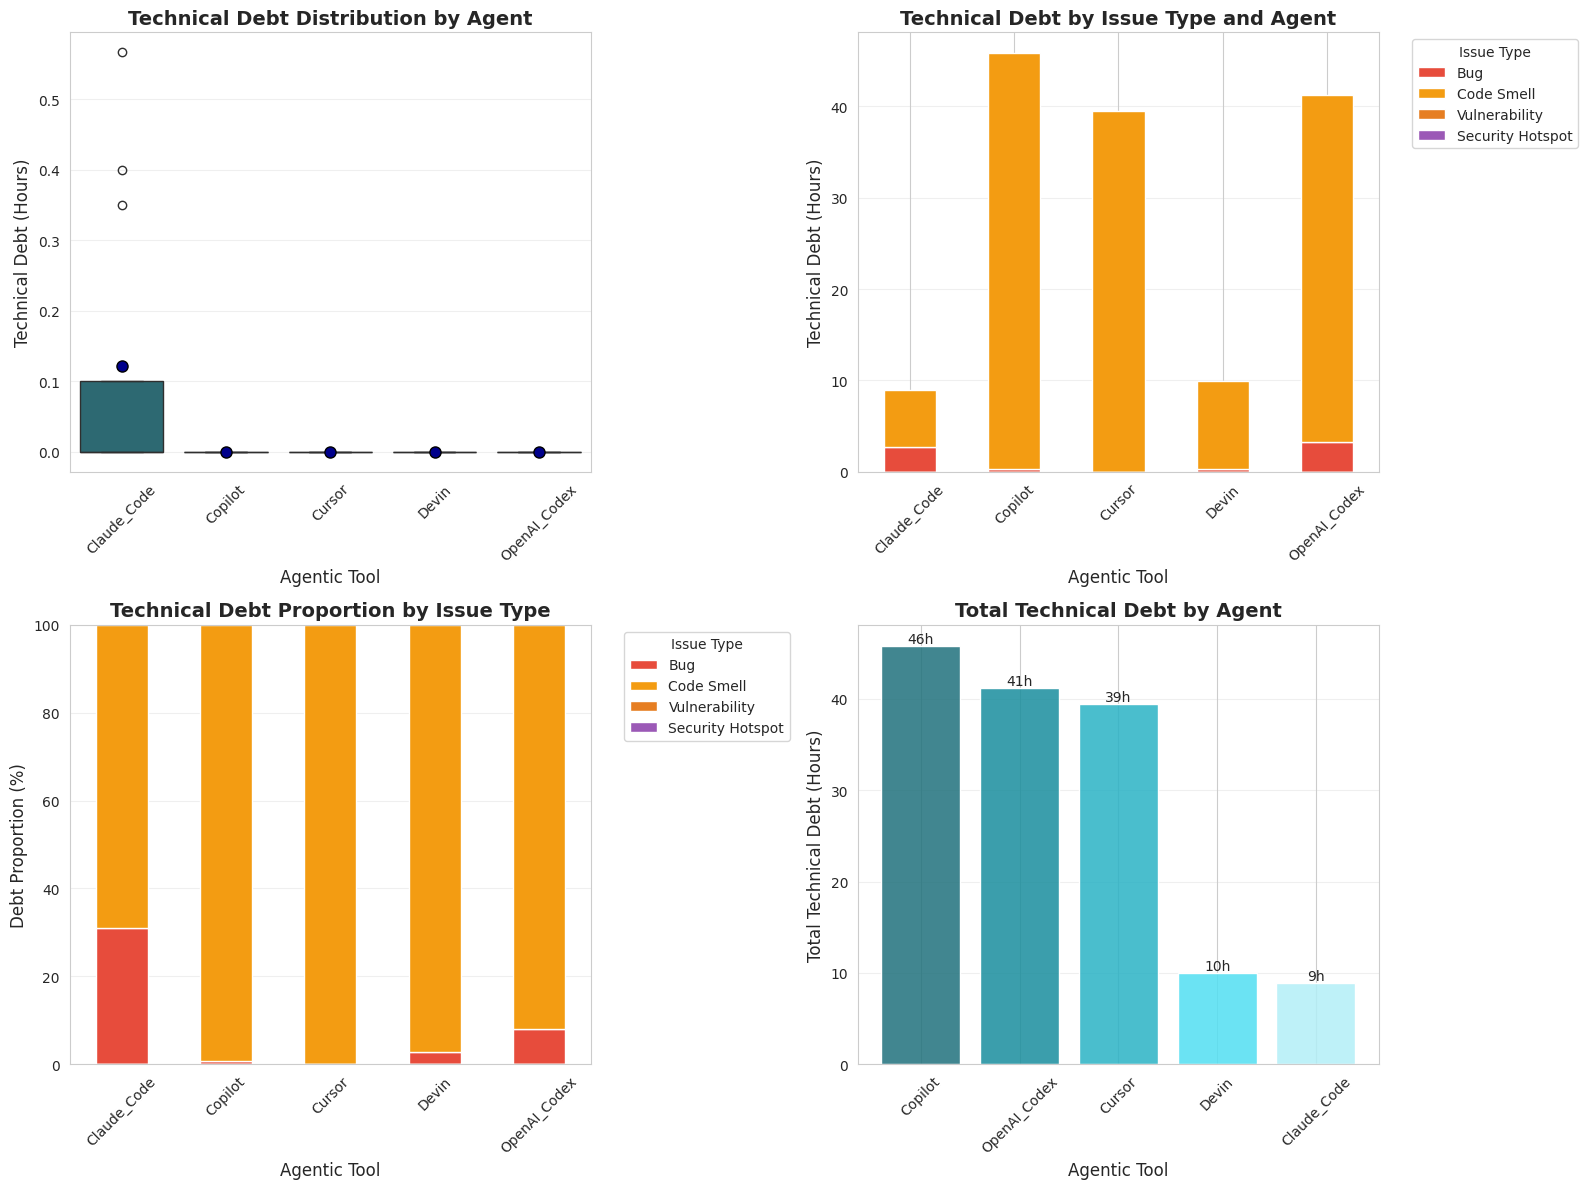

✓ Visualizations saved: technical_debt_analysis.png

7. KEY INSIGHTS FOR RESEARCH PAPER

▸ Highest total debt: Copilot (45.82 hours)
▸ Lowest total debt: Claude_Code (8.90 hours)
▸ Debt ratio: 5.15x

▸ Highest mean debt per PR: Cursor (0.99 hours/PR)

▸ Debt Composition by Issue Type:

  Claude_Code:
    Bug: 30.9%
    Code Smell: 69.1%
    Vulnerability: 0.0%
    Security Hotspot: 0.0%

  Copilot:
    Bug: 0.7%
    Code Smell: 99.3%
    Vulnerability: 0.0%
    Security Hotspot: 0.0%

  Cursor:
    Bug: 0.0%
    Code Smell: 100.0%
    Vulnerability: 0.0%
    Security Hotspot: 0.0%

  Devin:
    Bug: 2.7%
    Code Smell: 97.3%
    Vulnerability: 0.0%
    Security Hotspot: 0.0%

  OpenAI_Codex:
    Bug: 8.0%
    Code Smell: 92.0%
    Vulnerability: 0.0%
    Security Hotspot: 0.0%

TECHNICAL DEBT ANALYSIS COMPLETE

Files saved:
  - Technical_Debt_Statistics_by_Agent.csv
  - Technical_Debt_by_Issue_Type_and_Agent.csv
  - technical_debt_analysis.png
  - Technical_Debt_Dunn_Test.csv



In [ ]:
# ============================================================================
# TECHNICAL DEBT ANALYSIS FROM 4.All_PR_Sonar_Results.json
# ============================================================================

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp

print("="*100)
print("TECHNICAL DEBT ANALYSIS")
print("="*100)
print()

# Load the JSON data
with open(str(DATASET_DIR / 'All_PR_Sonar_Results.json'), 'r') as f:
    data = json.load(f)

print(f"Total PRs in dataset: {len(data)}")
print()

# ============================================================================
# 1. EXTRACT DEBT VALUES FROM ISSUES
# ============================================================================
print("="*100)
print("1. EXTRACTING DEBT VALUES FROM ISSUES")
print("="*100)
print()

def parse_debt_to_minutes(debt_str):
    """Convert debt string (e.g., '10min', '2h', '1d', '1h21min') to minutes"""
    if pd.isna(debt_str) or debt_str == '' or debt_str is None:
        return 0
    
    debt_str = str(debt_str).strip().lower()
    total_minutes = 0
    
    try:
        # Handle days (e.g., '1d', '2d')
        if 'd' in debt_str:
            days_part = debt_str.split('d')[0].strip()
            if days_part:
                total_minutes += int(days_part) * 480  # 8-hour workday
            debt_str = debt_str.split('d')[1] if len(debt_str.split('d')) > 1 else ''
        
        # Handle hours (e.g., '2h', '1h30')
        if 'h' in debt_str:
            hours_part = debt_str.split('h')[0].strip()
            if hours_part:
                total_minutes += int(hours_part) * 60
            debt_str = debt_str.split('h')[1] if len(debt_str.split('h')) > 1 else ''
        
        # Handle minutes (e.g., '30min', '21')
        if debt_str:
            # Remove 'min' if present
            debt_str = debt_str.replace('min', '').strip()
            if debt_str:
                total_minutes += int(debt_str)
        
        return total_minutes
    except (ValueError, AttributeError):
        # If parsing fails, return 0
        return 0

# Extract debt data
debt_data = []

for pr in data:
    pr_info = pr['pr_info']
    pr_number = pr_info['pr_number']
    pr_url = pr_info['pr_html_url']
    agent = pr_info['agent']
    issues = pr.get('issues', [])
    
    total_debt_minutes = 0
    issue_count = 0
    debt_by_type = {'BUG': 0, 'CODE_SMELL': 0, 'VULNERABILITY': 0, 'SECURITY_HOTSPOT': 0}
    debt_by_severity = {}
    
    for issue in issues:
        debt_str = issue.get('debt', issue.get('effort', ''))
        debt_minutes = parse_debt_to_minutes(debt_str)
        
        if debt_minutes > 0:
            total_debt_minutes += debt_minutes
            issue_count += 1
            
            # Track by issue type
            issue_type = issue.get('type', 'UNKNOWN')
            if issue_type in debt_by_type:
                debt_by_type[issue_type] += debt_minutes
            
            # Track by severity
            severity = issue.get('severity', 'UNKNOWN')
            debt_by_severity[severity] = debt_by_severity.get(severity, 0) + debt_minutes
    
    # Convert total debt to hours
    total_debt_hours = total_debt_minutes / 60
    
    debt_data.append({
        'pr_number': pr_number,
        'pr_url': pr_url,
        'agent': agent,
        'total_issues': len(issues),
        'issues_with_debt': issue_count,
        'total_debt_minutes': total_debt_minutes,
        'total_debt_hours': total_debt_hours,
        'debt_bug': debt_by_type['BUG'] / 60,
        'debt_code_smell': debt_by_type['CODE_SMELL'] / 60,
        'debt_vulnerability': debt_by_type['VULNERABILITY'] / 60,
        'debt_security_hotspot': debt_by_type['SECURITY_HOTSPOT'] / 60,
        **{f'debt_severity_{k}': v / 60 for k, v in debt_by_severity.items()}
    })

debt_df = pd.DataFrame(debt_data)

print(f"Total PRs with debt data: {len(debt_df)}")
print(f"PRs with debt > 0: {(debt_df['total_debt_hours'] > 0).sum()}")
print(f"Total technical debt: {debt_df['total_debt_hours'].sum():.2f} hours")
print()

# ============================================================================
# 2. DESCRIPTIVE STATISTICS BY AGENT
# ============================================================================
print("="*100)
print("2. DESCRIPTIVE STATISTICS - TECHNICAL DEBT BY AGENT")
print("="*100)
print()

debt_stats = []

for agent in sorted(debt_df['agent'].unique()):
    agent_data = debt_df[debt_df['agent'] == agent]['total_debt_hours']
    
    stats = {
        'Agent': agent,
        'N_PRs': len(agent_data),
        'PRs_with_Debt': (agent_data > 0).sum(),
        'Total_Debt_Hours': agent_data.sum(),
        'Mean_Hours': agent_data.mean(),
        'Median_Hours': agent_data.median(),
        'Std_Dev': agent_data.std(),
        'Min': agent_data.min(),
        'Q1': agent_data.quantile(0.25),
        'Q3': agent_data.quantile(0.75),
        'Max': agent_data.max()
    }
    debt_stats.append(stats)

debt_stats_df = pd.DataFrame(debt_stats)
print(debt_stats_df.to_string(index=False))
print()

# Save to CSV
debt_stats_df.to_csv(str(OUT_DIR / 'Technical_Debt_Statistics_by_Agent.csv'), index=False)
print("✓ Saved: Technical_Debt_Statistics_by_Agent.csv")
print()

# ============================================================================
# 3. DEBT BY ISSUE TYPE
# ============================================================================
print("="*100)
print("3. TECHNICAL DEBT BREAKDOWN BY ISSUE TYPE")
print("="*100)
print()

debt_by_type_agent = []

for agent in sorted(debt_df['agent'].unique()):
    agent_data = debt_df[debt_df['agent'] == agent]
    
    row = {
        'Agent': agent,
        'Bug_Debt_Hours': agent_data['debt_bug'].sum(),
        'Code_Smell_Debt_Hours': agent_data['debt_code_smell'].sum(),
        'Vulnerability_Debt_Hours': agent_data['debt_vulnerability'].sum(),
        'Security_Hotspot_Debt_Hours': agent_data['debt_security_hotspot'].sum(),
        'Total_Debt_Hours': agent_data['total_debt_hours'].sum()
    }
    
    # Calculate percentages
    total = row['Total_Debt_Hours']
    if total > 0:
        row['Bug_Pct'] = (row['Bug_Debt_Hours'] / total) * 100
        row['Code_Smell_Pct'] = (row['Code_Smell_Debt_Hours'] / total) * 100
        row['Vulnerability_Pct'] = (row['Vulnerability_Debt_Hours'] / total) * 100
        row['Security_Hotspot_Pct'] = (row['Security_Hotspot_Debt_Hours'] / total) * 100
    else:
        row['Bug_Pct'] = 0
        row['Code_Smell_Pct'] = 0
        row['Vulnerability_Pct'] = 0
        row['Security_Hotspot_Pct'] = 0
    
    debt_by_type_agent.append(row)

debt_type_df = pd.DataFrame(debt_by_type_agent)
print(debt_type_df.to_string(index=False))
print()

debt_type_df.to_csv(str(OUT_DIR / 'Technical_Debt_by_Issue_Type_and_Agent.csv'), index=False)
print("✓ Saved: Technical_Debt_by_Issue_Type_and_Agent.csv")
print()

# ============================================================================
# 4. STATISTICAL TESTS - KRUSKAL-WALLIS
# ============================================================================
print("="*100)
print("4. KRUSKAL-WALLIS TEST (Non-parametric ANOVA)")
print("="*100)
print()

# Prepare data for Kruskal-Wallis test
agent_groups = [debt_df[debt_df['agent'] == agent]['total_debt_hours'].values 
               for agent in sorted(debt_df['agent'].unique())]

h_stat, p_value = kruskal(*agent_groups)

print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_value:.4e}")
print()

if p_value < 0.05:
    print("✓ Significant difference detected (p < 0.05)")
    print("  → Agents differ significantly in technical debt introduced")
else:
    print("✗ No significant difference detected (p ≥ 0.05)")
print()

# Post-hoc Dunn test if significant
if p_value < 0.05:
    print("="*100)
    print("5. POST-HOC DUNN TEST (Pairwise Comparisons)")
    print("="*100)
    print()
    
    dunn_results = sp.posthoc_dunn(debt_df, val_col='total_debt_hours', group_col='agent', p_adjust='bonferroni')
    print("Dunn Test Results (p-values with Bonferroni correction):")
    print(dunn_results.to_string())
    print()
    
    dunn_results.to_csv(str(OUT_DIR / 'Technical_Debt_Dunn_Test.csv')
    print("✓ Saved: Technical_Debt_Dunn_Test.csv")
    print()

# ============================================================================
# 6. VISUALIZATIONS
# ============================================================================
print("="*100)
print("6. VISUALIZATIONS")
print("="*100)
print()

# Remove outliers for better visualization
debt_df_filtered = []
for agent in debt_df['agent'].unique():
    agent_data = debt_df[debt_df['agent'] == agent]['total_debt_hours']
    Q1 = agent_data.quantile(0.25)
    Q3 = agent_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    filtered = debt_df[(debt_df['agent'] == agent) & 
                       (debt_df['total_debt_hours'] >= lower_bound) & 
                       (debt_df['total_debt_hours'] <= upper_bound)]
    if len(filtered) > 0:
        debt_df_filtered.append(filtered)

# Handle case where all data might be filtered out
if len(debt_df_filtered) > 0:
    debt_df_clean = pd.concat(debt_df_filtered, ignore_index=True)
else:
    debt_df_clean = debt_df.copy()
    print("⚠ Warning: No data after outlier removal, using original data")

print(f"Original data points: {len(debt_df)}")
print(f"After removing outliers: {len(debt_df_clean)}")
print(f"Outliers removed: {len(debt_df) - len(debt_df_clean)}")
print()

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Box plot - Technical debt by agent
ax1 = axes[0, 0]
debt_df_clean_sorted = debt_df_clean.copy()
debt_df_clean_sorted['agent'] = pd.Categorical(debt_df_clean_sorted['agent'], 
                                                categories=sorted(debt_df_clean['agent'].unique()), 
                                                ordered=True)

colors = ["#21727dda", "#1a8e9eda", "#2bb3c5da", "#52dff2da", "#b3eff7da"]
sns.boxplot(data=debt_df_clean_sorted, x='agent', y='total_debt_hours', ax=ax1, 
            palette=colors, showmeans=True,
            meanprops=dict(marker='o', markerfacecolor='darkblue', markeredgecolor='black', markersize=8))
ax1.set_xlabel('Agentic Tool', fontsize=12)
ax1.set_ylabel('Technical Debt (Hours)', fontsize=12)
ax1.set_title('Technical Debt Distribution by Agent', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# 2. Stacked bar chart - Debt by issue type
ax2 = axes[0, 1]
debt_type_plot = debt_type_df.set_index('Agent')[['Bug_Debt_Hours', 'Code_Smell_Debt_Hours', 
                                                    'Vulnerability_Debt_Hours', 'Security_Hotspot_Debt_Hours']]
debt_type_plot.columns = ['Bug', 'Code Smell', 'Vulnerability', 'Security Hotspot']
debt_type_plot.plot(kind='bar', stacked=True, ax=ax2, 
                    color=['#E74C3C', '#F39C12', '#E67E22', '#9B59B6'])
ax2.set_xlabel('Agentic Tool', fontsize=12)
ax2.set_ylabel('Technical Debt (Hours)', fontsize=12)
ax2.set_title('Technical Debt by Issue Type and Agent', fontsize=14, fontweight='bold')
ax2.legend(title='Issue Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# 3. Percentage stacked bar - Debt proportion by issue type
ax3 = axes[1, 0]
debt_type_pct = debt_type_df.set_index('Agent')[['Bug_Pct', 'Code_Smell_Pct', 
                                                   'Vulnerability_Pct', 'Security_Hotspot_Pct']]
debt_type_pct.columns = ['Bug', 'Code Smell', 'Vulnerability', 'Security Hotspot']
debt_type_pct.plot(kind='bar', stacked=True, ax=ax3, 
                   color=['#E74C3C', '#F39C12', '#E67E22', '#9B59B6'])
ax3.set_xlabel('Agentic Tool', fontsize=12)
ax3.set_ylabel('Debt Proportion (%)', fontsize=12)
ax3.set_title('Technical Debt Proportion by Issue Type', fontsize=14, fontweight='bold')
ax3.legend(title='Issue Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.tick_params(axis='x', rotation=45)
ax3.set_ylim(0, 100)
ax3.grid(axis='y', alpha=0.3)

# 4. Total debt comparison
ax4 = axes[1, 1]
total_debt_by_agent = debt_stats_df.sort_values('Total_Debt_Hours', ascending=False)

# Ensure we have the right number of colors
agent_count = len(total_debt_by_agent)
colors_list = ["#21727dda", "#1a8e9eda", "#2bb3c5da", "#52dff2da", "#b3eff7da"]
colors_to_use = colors_list[:agent_count] if agent_count <= len(colors_list) else colors_list * (agent_count // len(colors_list) + 1)
colors_to_use = colors_to_use[:agent_count]

bars = ax4.bar(total_debt_by_agent['Agent'], total_debt_by_agent['Total_Debt_Hours'], 
               color=colors_to_use)
ax4.set_xlabel('Agentic Tool', fontsize=12)
ax4.set_ylabel('Total Technical Debt (Hours)', fontsize=12)
ax4.set_title('Total Technical Debt by Agent', fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}h',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(str(OUT_DIR / 'technical_debt_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualizations saved: technical_debt_analysis.png")
print()

# ============================================================================
# 7. KEY INSIGHTS
# ============================================================================
print("="*100)
print("7. KEY INSIGHTS FOR RESEARCH PAPER")
print("="*100)
print()

highest_debt_agent = debt_stats_df.loc[debt_stats_df['Total_Debt_Hours'].idxmax()]
lowest_debt_agent = debt_stats_df.loc[debt_stats_df['Total_Debt_Hours'].idxmin()]

print(f"▸ Highest total debt: {highest_debt_agent['Agent']} ({highest_debt_agent['Total_Debt_Hours']:.2f} hours)")
print(f"▸ Lowest total debt: {lowest_debt_agent['Agent']} ({lowest_debt_agent['Total_Debt_Hours']:.2f} hours)")

# Calculate debt ratio only if lowest debt is not zero
if lowest_debt_agent['Total_Debt_Hours'] > 0:
    debt_ratio = highest_debt_agent['Total_Debt_Hours'] / lowest_debt_agent['Total_Debt_Hours']
    print(f"▸ Debt ratio: {debt_ratio:.2f}x")
else:
    print(f"▸ Debt ratio: N/A (lowest debt is zero)")
print()

highest_mean = debt_stats_df.loc[debt_stats_df['Mean_Hours'].idxmax()]
print(f"▸ Highest mean debt per PR: {highest_mean['Agent']} ({highest_mean['Mean_Hours']:.2f} hours/PR)")
print()

# Debt composition
print("▸ Debt Composition by Issue Type:")
for _, row in debt_type_df.iterrows():
    print(f"\n  {row['Agent']}:")
    print(f"    Bug: {row['Bug_Pct']:.1f}%")
    print(f"    Code Smell: {row['Code_Smell_Pct']:.1f}%")
    print(f"    Vulnerability: {row['Vulnerability_Pct']:.1f}%")
    print(f"    Security Hotspot: {row['Security_Hotspot_Pct']:.1f}%")

print()
print("="*100)
print("TECHNICAL DEBT ANALYSIS COMPLETE")
print("="*100)
print()
print("Files saved:")
print("  - Technical_Debt_Statistics_by_Agent.csv")
print("  - Technical_Debt_by_Issue_Type_and_Agent.csv")
print("  - technical_debt_analysis.png")
if p_value < 0.05:
    print("  - Technical_Debt_Dunn_Test.csv")
print()
print("="*100)